# Author: Tamal Majumder


## Part-A  : (One-dimensional symmetrical random walk) 
#### a) Write a program to simulate a one-dimensional symmetric random walk that takes a step of length l = 1. You will need to know the inbuilt uniform random number generator [that generates random numbers uniformly between (0, 1)] in the programming language you are using. Assume initial position of the walker to be at zero.

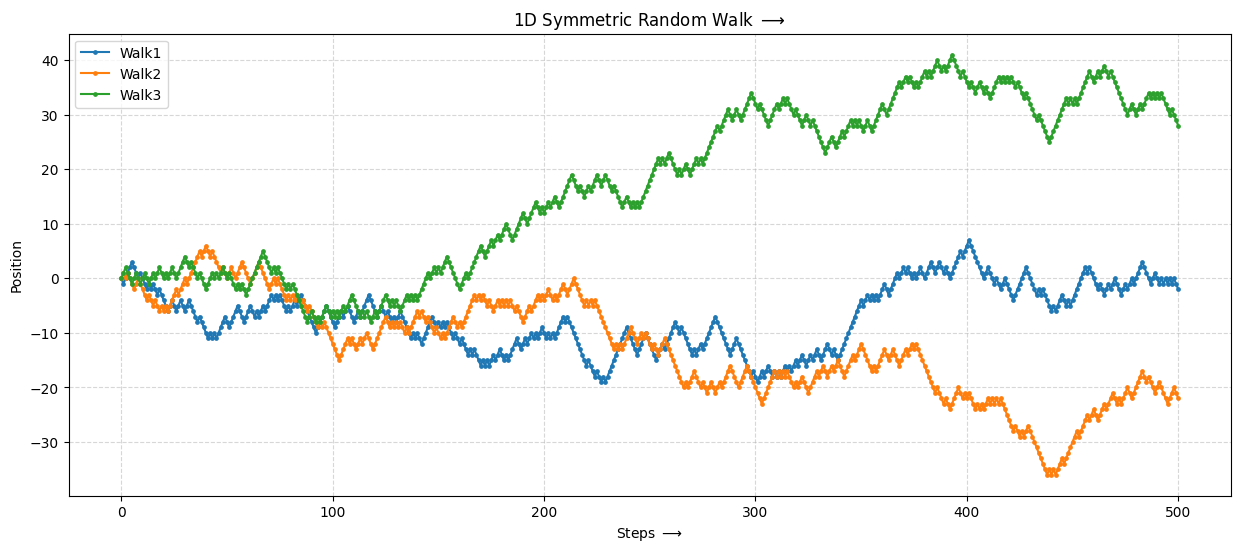

In [62]:
# Importing all the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy.stats import norm

#N =int(input("Enter the number of steps you want your Random walk to have "))
#n_exp=int(input("Number of time you want to simulate the experiment: "))

N =500
n_exp=3

#Defining a function which will return the final position of 1D Random Walk
def random_walk_1D(steps):
  x_pos = 0   #Starting position x= 0
  positions = np.arange(steps+1)
  pos = [x_pos]
  for i in range(steps):
    step_choice = random.uniform(0,1)
    if step_choice>0.5:
      x_pos = x_pos +1
    else:
      x_pos = x_pos -1
    pos.append(x_pos)
  return pos, positions

# P L O T
plt.figure(figsize=(15,6))
plt.title(r"1D Symmetric Random Walk $\longrightarrow$")
plt.xlabel(r"Steps $\longrightarrow$")
plt.ylabel("Position")
for i in range (1,n_exp+1):
  walk=random_walk_1D(N)
  Walk_n = random_walk_1D((N))
  plt.plot(Walk_n[1],Walk_n[0],ls='-',marker='o',markersize=2.4,label=f"Walk{i}")
  plt.legend()
plt.grid(True,ls='--', alpha=0.5)
plt.show()

#### 2) Using the program plot the probability density function (PDF) of reaching n after taking N steps, P(n, N).

In [74]:
#num_replications=int(input('Number of times we want to replicate this experiment:'))
num_replications=200000
RV_Y=[]
for i in range(num_replications):
  W=random_walk_1D(N)[0]
  RV_Y.append(W[-1])

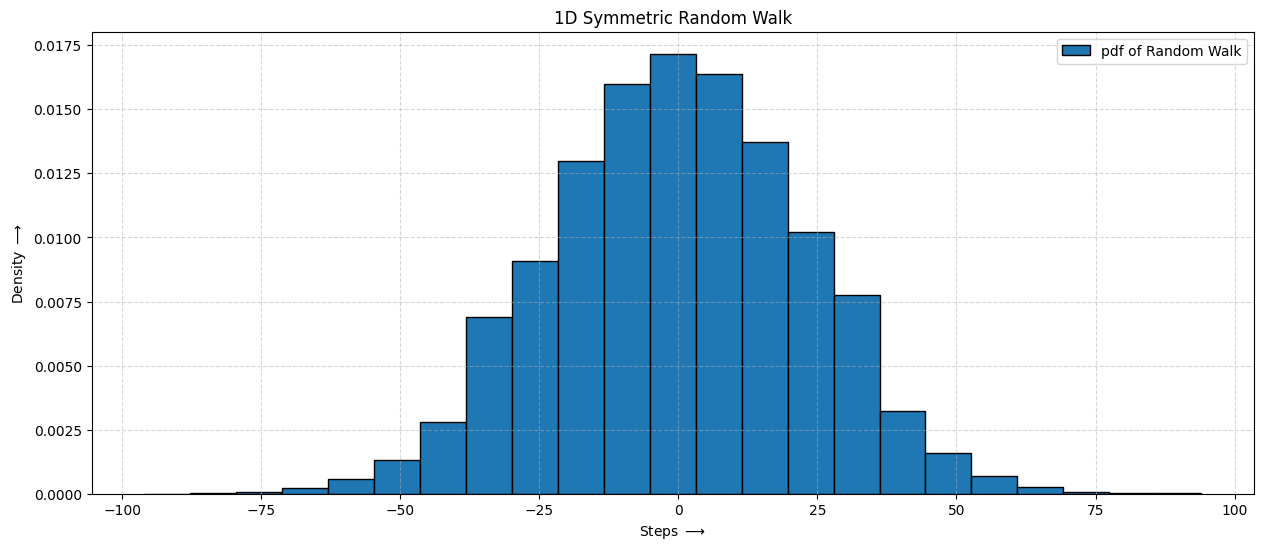

In [78]:
plt.figure(figsize=(15,6))
plt.title("1D Symmetric Random Walk")
plt.xlabel(r"Steps $\longrightarrow$")
plt.ylabel(r"Density $\longrightarrow$")
plt.hist(RV_Y,bins=23,edgecolor='k',density='true',label='pdf of Random Walk')
plt.grid(True,ls='--', alpha=0.5)
plt.legend()
plt.show()

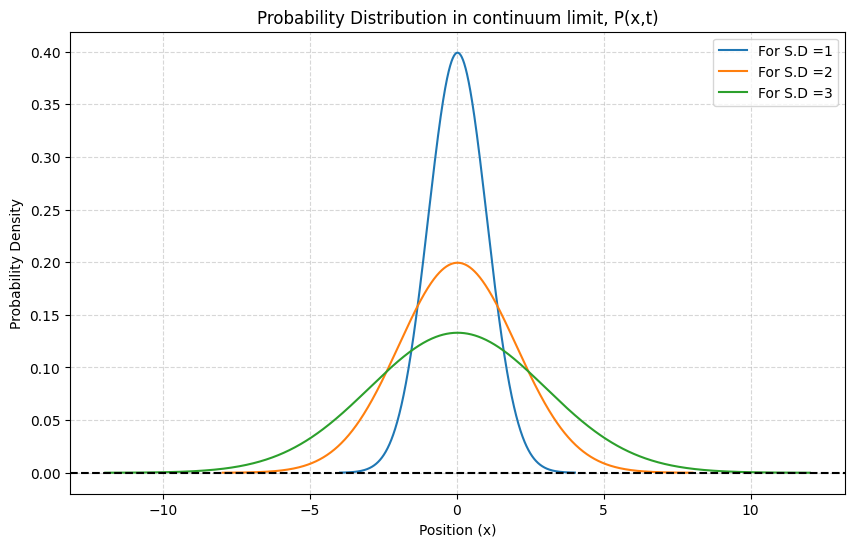

In [39]:
plt.figure(figsize=(10, 6))
std_exp=[1,2,3]
mean=np.mean(RV_Y)
for i in range(0,len(std_exp)):    
    x = np.linspace(mean - 4*std_exp[i], mean + 4*std_exp[i], 1000)
    gaussian_dist=norm.pdf(x,mean,std_exp[i])
    plt.plot(x, gaussian_dist,label=f'For S.D ={std_exp[i]}')
plt.title(f'Probability Distribution in continuum limit, P(x,t)')
plt.xlabel('Position (x)')
plt.ylabel('Probability Density')
plt.axhline(0,color='k',ls='--')
plt.grid(True,ls='--', alpha=0.5)
plt.legend()
plt.show()

#### 3) Match this PDF with the known analytical formula


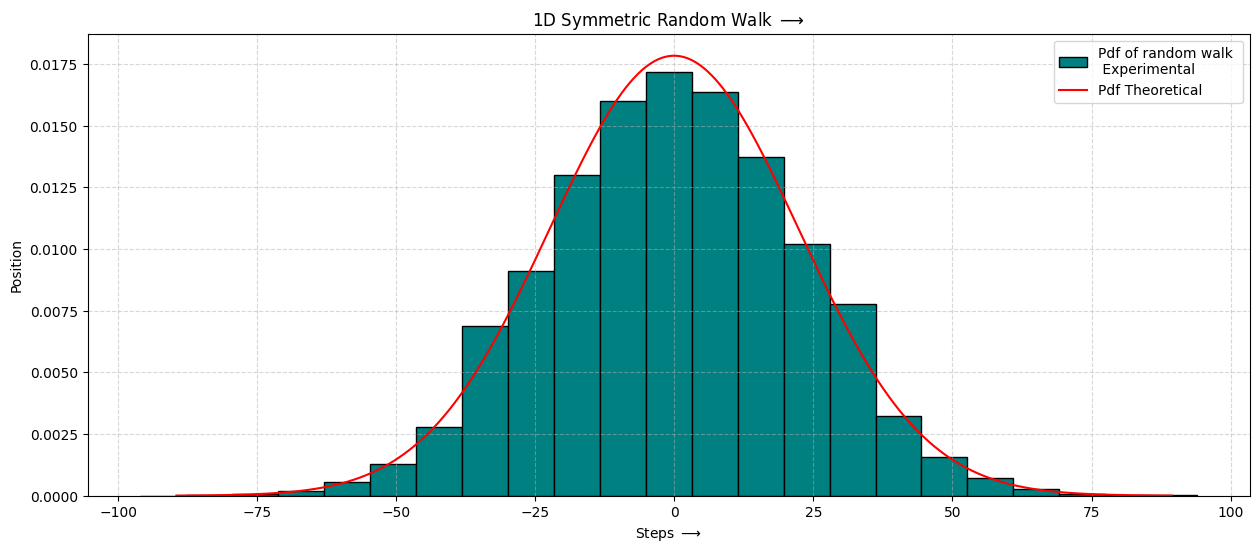

In [84]:
from scipy.stats import norm
plt.figure(figsize=(15,6))
plt.title(r"1D Symmetric Random Walk $\longrightarrow$")
plt.xlabel(r"Steps $\longrightarrow$")
plt.ylabel("Position")
plt.hist(RV_Y,bins=23,color='teal',edgecolor='k',density=True,label='Pdf of random walk \n Experimental')
plt.grid(True,ls='--', alpha=0.5)

mean=np.mean(RV_Y)
std=np.std(RV_Y)
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
gaussian_dist=norm.pdf(x,mean,std)
plt.plot(x, gaussian_dist,color='r',label='Pdf Theoretical')
plt.legend()
plt.show()

#### 4) Calculate the mean squared displacement (n²) - (n)² for different N. Plot it and try to match it with the theoretical prediction. How do you interpret this result?
 

In [85]:
# Mean Square Displacement
# steps = input("Input the number of steps ")
# num_walk = input("Input the number of walks ")
steps = 1000
num_walk = 300
N_s = np.arange(1,int(steps)+1,10)
msd = []

for N in N_s:
  final_pos = []
  for _ in range(int(num_walk)):
    pos, point = random_walk_1D(N)
    final_pos.append(pos[-1])

  mean_x_sq = np.mean(np.array(final_pos)**2)
  mean_x = np.mean(np.array(final_pos))
  msd.append(mean_x_sq-mean_x**2)

C:\Users\987ta\AppData\Local\Temp\ipykernel_8044\1014662683.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(N_s,N_s,'r--',color='k',label="Theoretical MSD")


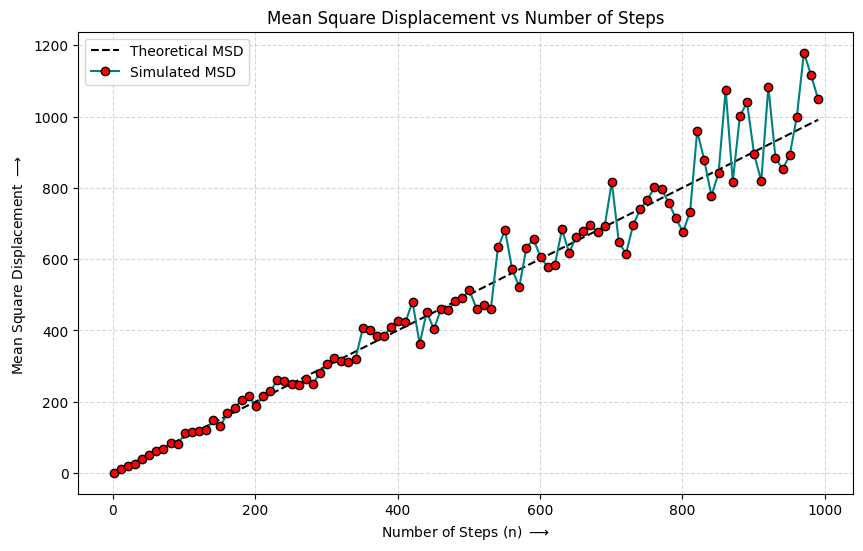

In [86]:
#Plotting
plt.figure(figsize=(10, 6))
plt.plot(N_s,N_s,'r--',color='k',label="Theoretical MSD")
plt.plot(N_s,msd,ls='-',marker='o',color='teal',markeredgecolor='k',markerfacecolor='red',label="Simulated MSD")
plt.title(f'Mean Square Displacement vs Number of Steps')
plt.xlabel(r'Number of Steps (n) $\longrightarrow$')
plt.ylabel(r'Mean Square Displacement $\longrightarrow$ ')
plt.legend()
plt.grid(True,ls='--', alpha=0.5)
plt.show()

# Part B : 2-D symmetric Random Walk
#### Write a program for a two-dimensional random walker that takes a step of length l = 1 after choosing a direction randomly and uniformly between [0, 2π). Plot several (at least 5) different random walks thus generated. Take total number of steps for each walk to be large (at least N~200).

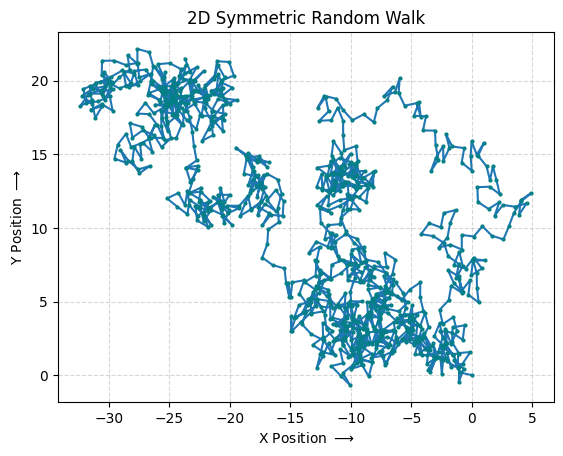

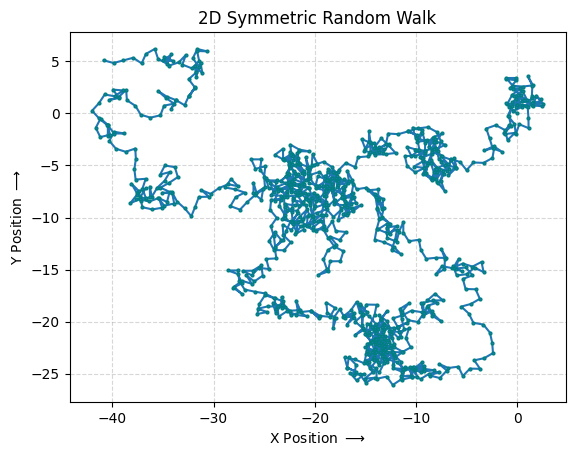

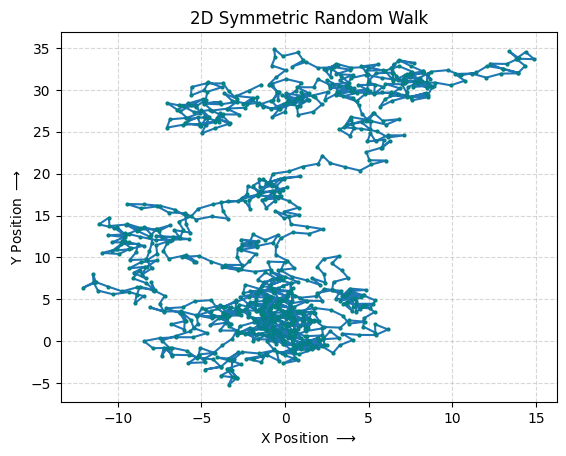

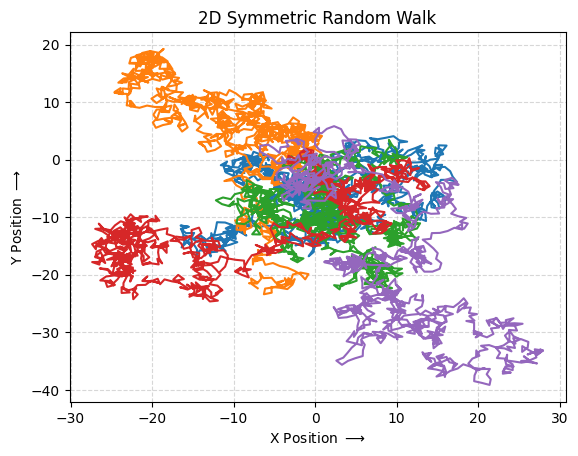

In [53]:
def random_walk_2D(num_steps):
  x_pos, y_pos = 0, 0  # Initial Position
  pos_x = [x_pos]
  pos_y = [y_pos]
  for _ in range(num_steps):
    angle = random.uniform(0,2*np.pi)
    x_pos += np.cos(angle)
    y_pos += np.sin(angle)
    # Randomly moving in the xy plane
    pos_x.append(x_pos)
    pos_y.append(y_pos)
  return pos_x, pos_y

#steps = input("Input the number of steps ")  ## put 1000
steps=1000 

# Plotting the 2D Random Walk
for i in range (3):
  walk = random_walk_2D(int(steps))
  plt.plot(walk[0],walk [1],ls='-',marker='o',markersize=2,markeredgecolor='teal')
  plt.xlabel (r'X Position $\longrightarrow$')
  plt.ylabel(r'Y Position $\longrightarrow$')
  plt.title('2D Symmetric Random Walk')
  plt.grid(True,ls='--', alpha=0.5)
  plt.show()

for i in range (5):
  walk = random_walk_2D(int(steps))
  plt.plot(walk[0],walk [1],ls='-')
  plt.xlabel (r'X Position $\longrightarrow$')
  plt.ylabel(r'Y Position $\longrightarrow$')
  plt.title('2D Symmetric Random Walk')
  plt.grid(True,ls='--', alpha=0.5)
plt.show()

## Part C ) Optional: Asymmetric random walk 

### Repeat the problem (A) for an asymmetric random walker where probability to take a step to left (p) is not equal to the probability to take a step to the right (q) but p + q = 1 For example, p = 0.7 q = 0.3
### i) The asymmetric random walk

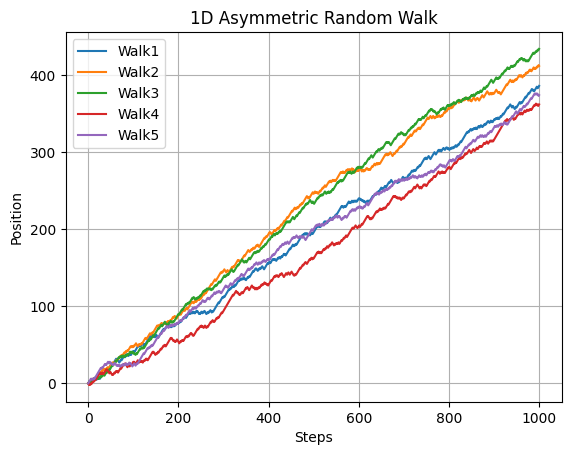

In [87]:
def asym_random_walk_1D(steps):
  x_pos = 0   #Starting position x= 0
  positions = np.arange(steps+1)
  pos = [x_pos]
  for i in range(steps):
    step_choice = random.uniform(0,1)
    
    if step_choice>0.3:
      x_pos = x_pos +1
    else:
      x_pos = x_pos -1
    pos.append(x_pos)
  return pos, positions

#step =int(input("Enter the number of steps you want your Asymmetric Random walk to have "))
step=1000
#Now plotting it
for i in range(5):
  Walk_bias = asym_random_walk_1D(int(step))
  plt.plot(Walk_bias[1],Walk_bias[0],label=f"Walk{i+1}")
  plt.grid()
  plt.title("1D Asymmetric Random Walk")
  plt.xlabel("Steps")
  plt.ylabel("Position")
plt.legend()
plt.show()


### ii) Type here please 

In [45]:
#num_replications_asy=int(input('Number of times we want to replicate this experiment:'))
num_replications_asy=200000
RV_Y_asy=[]
for i in range(num_replications_asy):
  W_asy=asym_random_walk_1D(step)[0]
  RV_Y_asy.append(W_asy[-1])

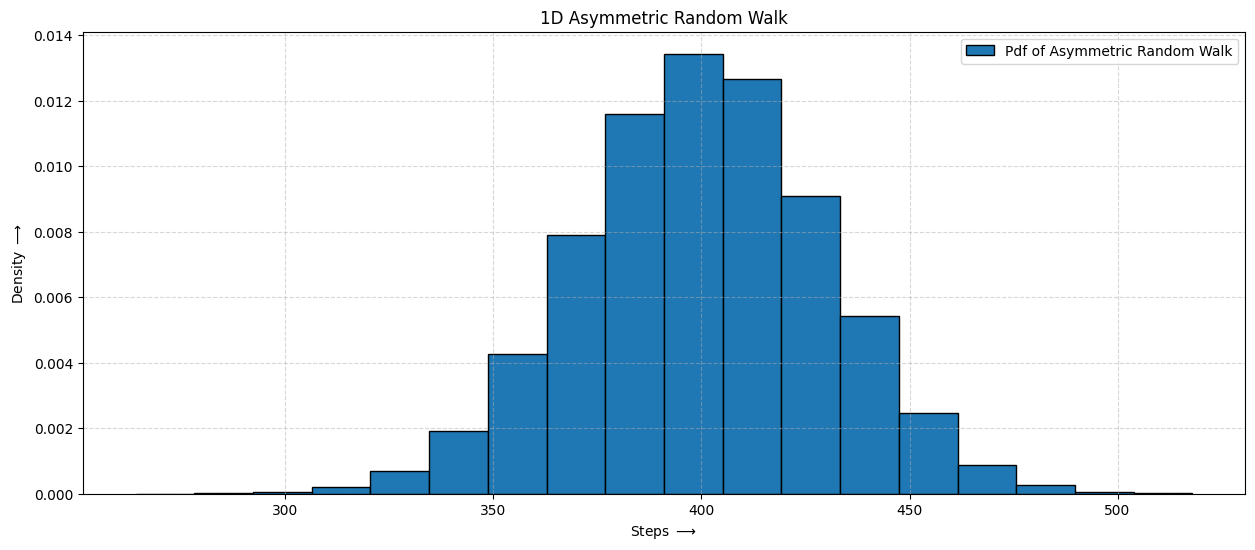

In [46]:
plt.figure(figsize=(15,6))
plt.title("1D Asymmetric Random Walk")
plt.xlabel(r"Steps $\longrightarrow$")
plt.ylabel(r"Density $\longrightarrow$")
plt.hist(RV_Y_asy,bins=18,edgecolor='k',density='true',label='Pdf of Asymmetric Random Walk')
plt.grid(True,ls='--', alpha=0.5)
plt.legend()
plt.show()

### iii) Type here please 

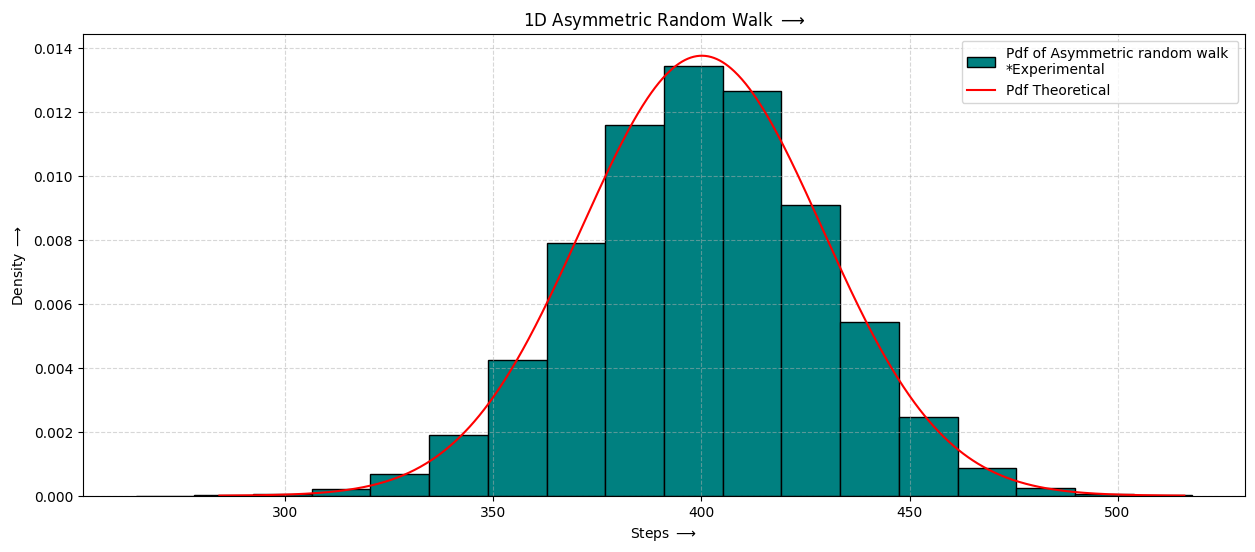

In [48]:
plt.figure(figsize=(15,6))
plt.title(r"1D Asymmetric Random Walk $\longrightarrow$")
plt.xlabel(r"Steps $\longrightarrow$")
plt.ylabel(r"Density $\longrightarrow$")
plt.hist(RV_Y_asy,bins=18,color='teal',edgecolor='k',density=True,label='Pdf of Asymmetric random walk \n*Experimental')
plt.grid(True,ls='--', alpha=0.5)

mean_asy=np.mean(RV_Y_asy)
std_asy=np.std(RV_Y_asy)
x_asy = np.linspace(mean_asy - 4*std_asy, mean_asy + 4*std_asy, 1000)
gaussian_dist_asy=norm.pdf(x_asy,mean_asy,std_asy)
plt.plot(x_asy, gaussian_dist_asy,color='r',label='Pdf Theoretical')
plt.legend()
plt.show()

### iv) Type question here

In [49]:
# Mean Square Displacement
#steps = input("Input the number of steps ")
#num_walk = input("Input the number of walks ")
steps = 1000
num_walk=300
N_s = np.arange(1,int(steps)+1,10)
msd = []
for N in N_s:
  final_pos = []
  for _ in range(int(num_walk)):
    pos, point = asym_random_walk_1D(N)
    final_pos.append(pos[-1])

  mean_x_sq = np.mean(np.array(final_pos)**2)
  mean_x = np.mean(np.array(final_pos))
  msd.append(mean_x_sq-mean_x**2)

C:\Users\987ta\AppData\Local\Temp\ipykernel_8044\2578128704.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(N_s,N_s,'r--',color='k',label="Theoretical MSD")


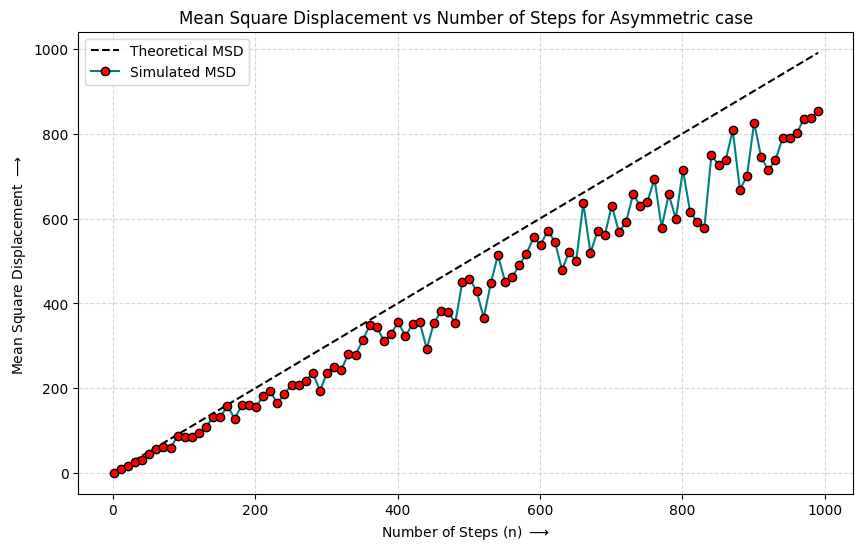

In [50]:
#Plotting
plt.figure(figsize=(10, 6))
plt.plot(N_s,N_s,'r--',color='k',label="Theoretical MSD")
plt.plot(N_s,msd,ls='-',marker='o',color='teal',markeredgecolor='k',markerfacecolor='red',label="Simulated MSD")
plt.title(f'Mean Square Displacement vs Number of Steps for Asymmetric case')
plt.xlabel(r'Number of Steps (n) $\longrightarrow$')
plt.ylabel(r'Mean Square Displacement $\longrightarrow$ ')
plt.legend()
plt.grid(True,ls='--', alpha=0.5)
plt.show()